In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
import warnings

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
warnings.filterwarnings('ignore')

In [3]:
dff = pd.read_excel(r"excel\Fact_cluster.xlsx")

In [29]:
def analisis_var (var):
    res = dff.groupby(var).agg(cant=("Tienda", "count"), venta=(' Vta.', "sum"))

    # 2. Operación vectorizada para convertir a porcentaje (0 a 100)
    res["venta"] = (res["venta"] / dff[' Vta.'].sum()) * 100

    print(res)


In [30]:
dff.columns

Index(['Grupo EO', 'Obs', 'Tienda', 'EsMultif', 'formato', 'formato2',
       'ubicacion', 'cluster', 'Cluster Comercial', 'Cluster NSE',
       'Cluster NSE Comercial', 'Cluster_Comercial', 'Metros Cuadrados',
       'Rangom2', 'Gondorack', 'Centro comercial', 'Venta Asistida',
       'Carriboys', 'almacén en subsuelo', 'Almacén 1er piso',
       'Almacén 2do o 3er piso', 'Niveles de piso de venta', 'Montacargas',
       'Stoka', 'Niveles Rack almacenaje', 'Rampa mecánica en recepción',
       'Área Electro', 'Delivea', 'Tiene Self check out', 'Producción Propia',
       'Count', ' Vta.', ' VtaAA.', ' %VarVta', ' VtaUn.', ' VtaUnAA.',
       ' %VarVtaUnid', 'JEq', 'JEqAA', ' %VarHrs', ' ProdVN', ' ProdVNAA',
       ' %VarProdVN', ' ProdVU', ' ProdVUAA', ' %VarProdVU', 'Abarrotes',
       'Frescos', 'Bazar', 'Electro', 'Hogar', 'Textil', '%Abarrotes',
       '%Frescos', '%Bazar', '%Electro', '%Hogar', '%Textil', 'Abarrotes.1',
       'Frescos.1', 'Bazar.1', 'Electro.1', 'Hogar.1', 'Tex

In [31]:
dff.head(3)

,Grupo EO,Obs,Tienda,EsMultif,formato,formato2,ubicacion,cluster,Cluster Comercial,Cluster NSE,Cluster NSE Comercial,Cluster_Comercial,Metros Cuadrados,Rangom2,Gondorack,Centro comercial,Venta Asistida,Carriboys,almacén en subsuelo,Almacén 1er piso,Almacén 2do o 3er piso,Niveles de piso de venta,Montacargas,Stoka,Niveles Rack almacenaje,Rampa mecánica en recepción,Área Electro,Delivea,Tiene Self check out,Producción Propia,Count,Vta.,VtaAA.,%VarVta,VtaUn.,VtaUnAA.,%VarVtaUnid,JEq,JEqAA,%VarHrs,ProdVN,ProdVNAA,%VarProdVN,ProdVU,ProdVUAA,%VarProdVU,Abarrotes,Frescos,Bazar,Electro,Hogar,Textil,%Abarrotes,%Frescos,%Bazar,%Electro,%Hogar,%Textil,Abarrotes.1,Frescos.1,Bazar.1,Electro.1,Hogar.1,Textil.1,%Abarrotes.1,%Frescos.1,%Bazar.1,%Electro.1,%Hogar.1,%Textil.1
0,Li_Hiper A,HIPER_Lima + Callao_A_A,P010_Caminos del Inca - PVS,Normal,PLAZA VEA SUPER,HIPER,Lima + Callao,A2,A2,A,A,A3,3507,A,No,Sí,Sí,No,Sí,No,No,1 nivel,Sí,Sí,3,Sí,Sí,No,Sí,SI,7,1.420428e+08,1.388942e+08,0.022669,1.703892e+07,1.728548e+07,-0.014264,1408.087171,1430.645674,-0.015768,100876.406551,97085.002695,0.039052,12100.759188,12082.290325,0.001529,77206869.70,55908659.07,4688314.91,1161987.29,2617376.54,459566.38,0.543547,0.393604,0.033006,0.008181,0.018427,0.003235,9267535.22,6943381.548,422598.0,99701.00,276463,29245,0.543904,0.407501,0.024802,0.005851,0.016225,0.001716
1,Li_Hiper A,HIPER_Lima + Callao_A_A,P064_Miraflores - PVH,Normal,PLAZA VEA,HIPER,Lima + Callao,A3,A3,A,A,A3,4439,A,No,No,Sí,Sí,No,Sí,No,2 niveles,No,Sí,4,No,Sí,Sí,Sí,NO,7,1.108209e+08,1.144018e+08,-0.031301,1.308530e+07,1.387232e+07,-0.056733,1169.218781,1172.414624,-0.002726,94782.023175,97577.972062,-0.028653,11191.489726,11832.262750,-0.054155,60674604.14,36418329.44,4958592.82,2495516.30,3319154.57,2954724.33,0.547501,0.328623,0.044744,0.022518,0.029951,0.026662,7487422.89,4431450.085,441541.0,245417.00,320553,158916,0.572201,0.338659,0.033743,0.018755,0.024497,0.012145
2,Li_Hiper A,HIPER_Lima + Callao_A_A,P081_La Molina - PVH,Normal,PLAZA VEA,HIPER,Lima + Callao,A3,A3,A,A,A3,4506,A,No,Sí,Sí,Sí,Sí,No,No,1 nivel,Sí,Sí,2,Sí,Sí,No,Sí,SI,7,1.099489e+08,1.160620e+08,-0.052671,1.297132e+07,1.403541e+07,-0.075815,1228.437362,1306.207326,-0.059539,89503.056941,88854.185166,0.007303,10559.200115,10745.160657,-0.017306,59720794.63,30107323.32,5644845.09,7262262.83,3360846.65,3852826.65,0.543169,0.273830,0.051341,0.066051,0.030567,0.035042,7396965.22,3681868.965,466181.0,916123.75,319033,191144,0.570256,0.283847,0.035939,0.070627,0.024595,0.014736


In [32]:
analisis_var ("EsMultif")

                cant      venta
EsMultif                       
Multifuncional    19   2.949668
Normal            87  97.050332


In [33]:
analisis_var ("formato2")

          cant      venta
formato2                 
EXPRESS      5   0.470308
HIPER       73  87.936358
SUPER       21   6.865983
VIVANDA      7   4.727351


In [34]:
analisis_var ("ubicacion")

               cant      venta
ubicacion                     
Lima + Callao    70  61.488964
Provincia        36  38.511036


In [46]:

analisis_var ('Cluster NSE')

             cant      venta
Cluster NSE                 
A              18  24.364406
B              42  43.287647
C              35  28.129371
EX              5   0.470308
V               6   3.748268


In [35]:
analisis_var ("cluster")

         cant      venta
cluster                 
A1          2   0.655884
A2          7   9.162135
A3          9  14.546387
B1          5   1.858379
B2         17  14.690259
B3         20  26.739010
C1         10   1.520040
C2          8   4.299410
C3         17  22.309921
EX          5   0.470308
V1          5   3.390568
V2          1   0.357700


In [36]:
analisis_var ("Metros Cuadrados")

                  cant     venta
Metros Cuadrados                
293                  1  0.064789
343                  1  0.101782
400                  1  0.142099
486                  1  0.132590
504                  1  0.208605
...                ...       ...
5030                 1  1.981875
5216                 1  1.665978
5675                 1  0.995207
6916                 1  1.227697
7079                 1  1.525046

[104 rows x 2 columns]


In [38]:
analisis_var ("Rangom2")

           cant      venta
Rangom2                   
1000-        15   2.269981
1000-2000    23  13.160111
2000-3000    13   8.876511
3000-4000    24  30.814648
4000-5000    20  26.925010
5000+         4   6.400596
A             7  11.553143


In [39]:
analisis_var ("Gondorack") ###

           cant      venta
Gondorack                 
-             2   0.735870
No           76  68.371883
Sí           28  30.892248


In [40]:
analisis_var ("Centro comercial")

                  cant      venta
Centro comercial                 
-                    2   0.735870
No                  55  35.108775
Sí                  49  64.155355


In [41]:

analisis_var ("Venta Asistida")

                cant      venta
Venta Asistida                 
-                  2   0.735870
No                43  24.014565
Sí                61  75.249566


In [42]:


analisis_var ("Carriboys")

           cant      venta
Carriboys                 
-             2   0.735870
No           68  53.686152
Sí           36  45.577979


In [43]:


analisis_var ("Área Electro")

              cant      venta
Área Electro                 
-                2   0.735870
No              33  13.763470
Sí              71  85.500661


In [45]:

analisis_var ("Delivea")

         cant      venta
Delivea                 
-           2   0.735870
No         81  71.580742
Sí         23  27.683389


In [ ]:

analisis_var ("Producción Propia")

                   cant      venta
Producción Propia                 
NO                   69  56.997376
SI                   37  43.002624


In [109]:
cat_EsMultif = {"Multifuncional":0, "Normal":1}
cat_ubicacion = {"Lima + Callao":1, "Provincia":0}
cat_cluster = { "BC1":1, "BC2":2, "BC3":3, "A1":4, "A2":5, "A3":6}
cat_cc = {"Sí":1, "No":0, "-":0}
cat_venta_asistida = {"Sí":1, "No":0, "-":0}
cat_electro = {"Sí":1, "No":0, "-":0}
cat_delivea = {"Sí":1, "No":0, "-":0}
cat_prodprop = {"SI":1, "NO":0}

dff["cat_EsMultif"] = dff["EsMultif"].map(cat_EsMultif)
dff["cat_ubicacion"] = dff["ubicacion"].map(cat_ubicacion)
dff["cat_cluster"] = dff["Cluster_Comercial"].map(cat_cluster)
dff["cat_cc"] = dff["Centro comercial"].map(cat_cc)
dff["cat_venta_asistida"] = dff["Venta Asistida"].map(cat_venta_asistida)
dff["cat_electro"] = dff["Área Electro"].map(cat_electro)
dff["cat_delivea"] = dff["Delivea"].map(cat_delivea)
dff["cat_prodprop"] = dff["Producción Propia"].map(cat_prodprop)
dff["ratio_frescos"] = dff['%Frescos']
dff["ratio_abarrotes"] = dff['%Abarrotes']

dff["norm_m2"] = np.log(dff["Metros Cuadrados"])
dff["norm_venta"] = np.log(dff[' Vta.'])
dff["norm_jeq"] = np.log(dff["JEq"])

dff["norm_m2"] = dff["Metros Cuadrados"]
dff["norm_venta"] = dff[' Vta.']
dff["norm_jeq"] = dff["JEq"]

In [123]:
features_cluster = [
    # "cat_EsMultif",
    # "cat_ubicacion",
    "cat_cluster",
    "cat_cc",
    # "cat_venta_asistida",
    # "cat_electro",
    "cat_delivea",
    # "cat_prodprop",
    "ratio_frescos",
    "ratio_abarrotes",
    "norm_m2",
    "norm_venta",
    "norm_jeq"
]

In [124]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [125]:
dff_hiper_lima = dff[(dff["formato2"]=="HIPER")&(dff["ubicacion"]!="Provincia")]
X = dff_hiper_lima[features_cluster].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features_cluster)

X_scaled_df["norm_venta"] = X_scaled_df["norm_venta"] * 1

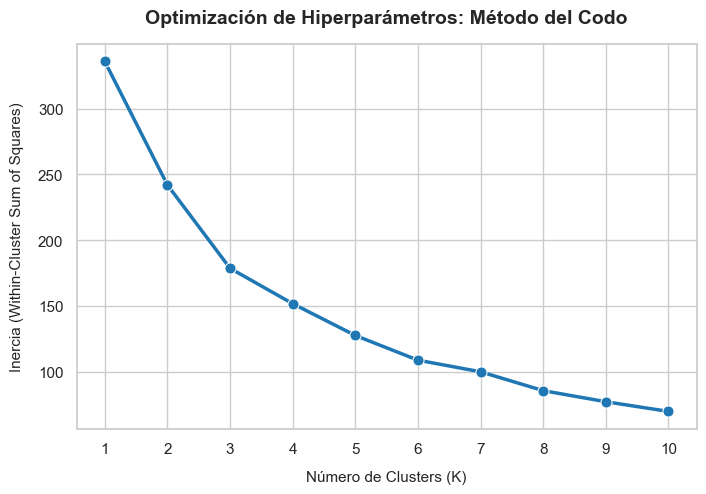

In [126]:
# 2. Búsqueda iterativa del hiperparámetro K (Inercia / WCSS)
inercia_valores = []
k_rango = range(1, 11)

for k in k_rango:
    # n_init='auto' optimiza la inicialización según la versión de sklearn
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_df)
    inercia_valores.append(kmeans.inertia_)

# 3. Estructuración de métricas para la visualización
df_elbow = pd.DataFrame({"K": list(k_rango), "Inercia": inercia_valores})

# 4. Construcción del gráfico de optimización utilizando Seaborn
sns.set_theme(style="whitegrid")

# Inicializar gráfico sin llamar a .figure() para respetar el entorno del notebook
fig, ax = plt.subplots(figsize=(8, 5))

# Plot lineal con marcadores para identificar el punto de inflexión geométrico
sns.lineplot(
    data=df_elbow,
    x="K",
    y="Inercia",
    marker="o",
    markersize=8,
    linewidth=2.5,
    color="#1f77b4",
    ax=ax,
)

# Configuración de etiquetas y jerarquía visual del canvas
ax.set_title(
    "Optimización de Hiperparámetros: Método del Codo",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Número de Clusters (K)", fontsize=11, labelpad=10)
ax.set_ylabel("Inercia (Within-Cluster Sum of Squares)", fontsize=11, labelpad=10)
ax.set_xticks(list(k_rango))

# Guardado asíncrono y renderizado limpio del objeto
plt.savefig("metodo_codo_clusters.png", dpi=300, bbox_inches="tight")

In [127]:
num_clusters = 4

X = dff_hiper_lima[features_cluster].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features_cluster)
X_scaled_df["norm_venta"] = X_scaled_df["norm_venta"] * 1
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
dff_hiper_lima["cluster_asignado"] = kmeans.fit_predict(X_scaled_df)

In [129]:
dff_hiper_lima.to_excel("revisar7.xlsx", index=False)

In [130]:
from sklearn.metrics import silhouette_score

# Calcular el score global
score = silhouette_score(X_scaled_df, dff_hiper_lima["cluster_asignado"])
print(f"Silhouette Score Global: {score:.4f}")

Silhouette Score Global: 0.2474


In [131]:
print(dff_hiper_lima.groupby("cluster_asignado").size())

cluster_asignado
0    12
1     5
2     7
3    18
dtype: int64


In [132]:
# Analizar los centroides en los valores reales de negocio
resumen_clusters = dff_hiper_lima.groupby("cluster_asignado").agg(
    total_tiendas=("Metros Cuadrados", "count"),
    media_m2=("Metros Cuadrados", "mean"),
    media_venta=(" Vta.", "mean"),
    media_frescos=("%Frescos", "mean"),
    media_abarrotes=("%Abarrotes", "mean"),
    tasa_multifuncional=("EsMultif", lambda x: (x == "Multifuncional").mean() * 100),
    prod_promedio_hh=(' Vta.', lambda x: (x.sum() / dff_hiper_lima.loc[x.index, "JEq"].sum())) # Productividad real del grupo
).reset_index()

print(resumen_clusters)

   cluster_asignado  total_tiendas     media_m2   media_venta  media_frescos  \
0                 0             12  2816.666667  4.396087e+07       0.159746   
1                 1              5  4999.800000  6.163639e+07       0.114081   
2                 2              7  3796.857143  1.023572e+08       0.310529   
3                 3             18  4226.555556  8.750342e+07       0.164272   

   media_abarrotes  tasa_multifuncional  prod_promedio_hh  
0         0.535496                  0.0      75911.406735  
1         0.424211                  0.0      87224.768600  
2         0.553159                  0.0      90667.558364  
3         0.499655                  0.0      97726.315202  


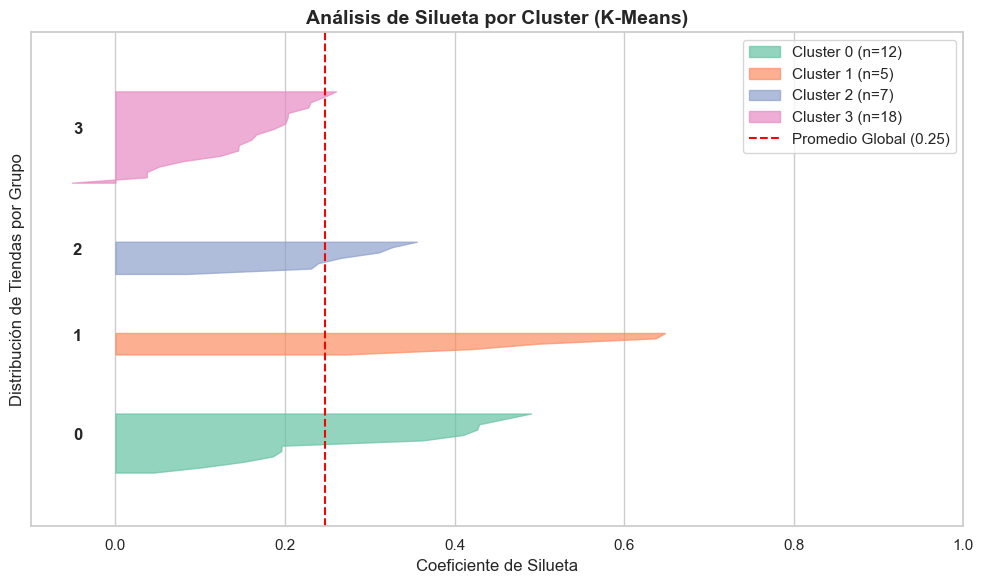

In [133]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import silhouette_samples, silhouette_score

# 1. Configuración de estilo y contexto visual para el gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Calcular métricas de silueta
# X_scaled_df contiene tus datos estandarizados y ponderados
cluster_labels = dff_hiper_lima["cluster_asignado"].values
silhouette_vals = silhouette_samples(X_scaled_df, cluster_labels)
silhouette_avg = silhouette_score(X_scaled_df, cluster_labels)

# 3. Construcción del gráfico de silueta por bloques
y_lower = 10
palette = sns.color_palette("Set2", n_colors=num_clusters)

for i in range(num_clusters):
    # Filtrar y ordenar los valores de silueta para el cluster i de forma vectorizada
    ith_cluster_silhouette_vals = silhouette_vals[cluster_labels == i]
    ith_cluster_silhouette_vals.sort()

    size_cluster_i = ith_cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i

    # Dibujar el área del cluster relleno con color de la paleta
    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_vals,
        facecolor=palette[i],
        edgecolor=palette[i],
        alpha=0.7,
        label=f"Cluster {i} (n={size_cluster_i})",
    )

    # Añadir la etiqueta del número de cluster al lado del bloque
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontweight="bold")

    # Calcular el inicio del siguiente bloque dejando un espacio
    y_lower = y_upper + 10

# 4. Línea discontinua que representa el promedio global
plt.axvline(
    x=silhouette_avg,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Promedio Global ({silhouette_avg:.2f})",
)

# 5. Buenas prácticas de etiquetado y títulos
plt.title(
    "Análisis de Silueta por Cluster (K-Means)", fontsize=14, fontweight="bold"
)
plt.xlabel("Coeficiente de Silueta", fontsize=12)
plt.ylabel("Distribución de Tiendas por Grupo", fontsize=12)

# Ajustar límites del gráfico basados en los coeficientes posibles [-1, 1]
plt.xlim([-0.1, 1.0])
plt.ylim([0, y_lower])

# Quitar los números del eje Y ya que los bloques representan las tiendas individuales
plt.gca().get_yaxis().set_ticks([])

plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

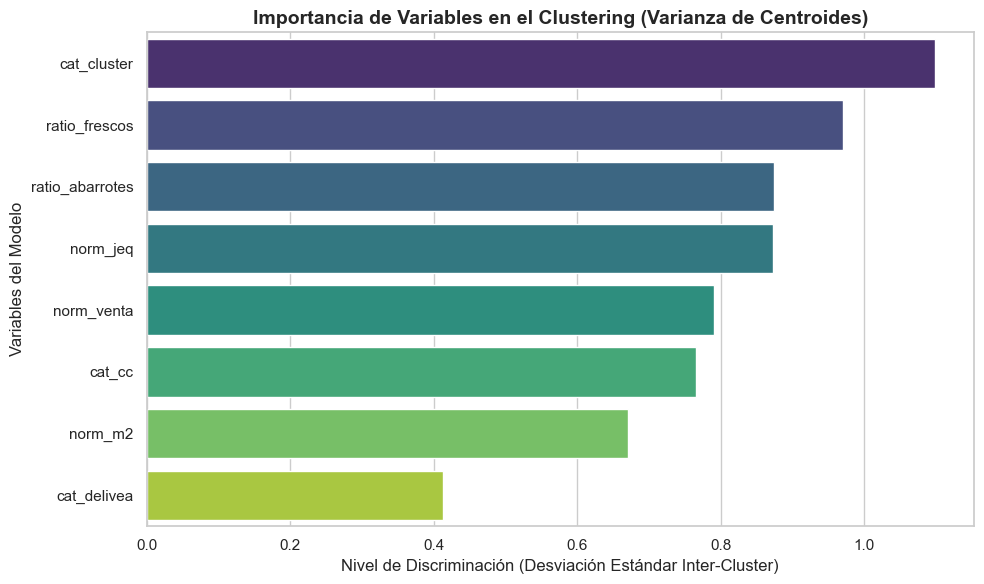


--- Tabla de Importancia de Variables ---
| Variable        |   Importancia |
|:----------------|--------------:|
| cat_cluster     |      1.09834  |
| ratio_frescos   |      0.971267 |
| ratio_abarrotes |      0.874329 |
| norm_jeq        |      0.873567 |
| norm_venta      |      0.790994 |
| cat_cc          |      0.766431 |
| norm_m2         |      0.671587 |
| cat_delivea     |      0.413121 |


In [134]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Calcular los centroides de cada cluster en la escala que usó el KMeans
# Agrupamos la matriz escalada (X_scaled_df) según los clusters asignados
centroides_scaled = X_scaled_df.groupby(
    dff_hiper_lima["cluster_asignado"]
).mean()

# 2. Calcular la importancia como la varianza (o desviación estándar) entre los centroides
# A mayor varianza entre clusters, más peso tuvo la variable para definir los grupos
importancia_vars = (
    centroides_scaled.std(ddof=0).sort_values(ascending=False).reset_index()
)
importancia_vars.columns = ["Variable", "Importancia"]

# 3. Configuración visual del gráfico con Seaborn
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Crear gráfico de barras horizontales
sns.barplot(
    x="Importancia",
    y="Variable",
    data=importancia_vars,
    palette="viridis",
    hue="Variable",
    legend=False,
)

# 4. Buenas prácticas de etiquetado y títulos
plt.title(
    "Importancia de Variables en el Clustering (Varianza de Centroides)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Nivel de Discriminación (Desviación Estándar Inter-Cluster)", fontsize=12)
plt.ylabel("Variables del Modelo", fontsize=12)

plt.tight_layout()
plt.show()

# 5. Mostrar la tabla de pesos en consola
print("\n--- Tabla de Importancia de Variables ---")
print(importancia_vars.to_markdown(index=False))